# Harry Potter Knowledge Graph — Web Data Mining Project

## Installation & Library Imports


In [64]:
!pip install rdflib requests spacy owlready2 pykeen torch \
    scikit-learn matplotlib seaborn pandas numpy tqdm
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 12.8/12.8 MB 88.5 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, json, time, logging, warnings
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from owlready2 import *
from rdflib import Graph, URIRef, Literal, Namespace, RDF, RDFS, OWL, XSD
from rdflib.namespace import SKOS
import random
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import re as _re

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

# Create project directory tree
for d in ['data/samples', 'kg_artifacts', 'reports', 'models', 'src']:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## Data Acquisition via Wikidata on Harry Potter


In [3]:
WIKIDATA_SPARQL = "https://query.wikidata.org/sparql"
HEADERS = {"User-Agent": "HPProject/1.0"}

QUERIES = {
    "series": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          ?book wdt:P179 wd:Q8337 .
          ?char wdt:P1441 ?book .
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        } LIMIT 300
    """,
    "hogwarts": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          ?char wdt:P69 wd:Q25975 .
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        } LIMIT 300
    """,
    "universe": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          ?char wdt:P1080 wd:Q5410773 .
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        } LIMIT 300
    """,
    "manual": """
        SELECT DISTINCT ?char ?charLabel ?genderLabel WHERE {
          VALUES ?char {
            wd:Q3244512 wd:Q180659 wd:Q184805 wd:Q170687 wd:Q174904
            wd:Q174921 wd:Q217246 wd:Q229054 wd:Q236306 wd:Q260819
            wd:Q264983 wd:Q273930 wd:Q274466 wd:Q294927 wd:Q312965
            wd:Q313226 wd:Q355566 wd:Q359457 wd:Q382274 wd:Q392049
            wd:Q435651 wd:Q464118 wd:Q700705 wd:Q734209 wd:Q850756
            wd:Q866225 wd:Q936765 wd:Q975871 wd:Q1043120 wd:Q1124106
            wd:Q1183173 wd:Q1230184 wd:Q1397671 wd:Q1421901 wd:Q1525851
            wd:Q1574844 wd:Q1637868 wd:Q1682310 wd:Q1770841 wd:Q1972781
            wd:Q2099744 wd:Q2265598 wd:Q2380867 wd:Q2674728 wd:Q2737248
            wd:Q3221958 wd:Q3271644 wd:Q4973503 wd:Q5256612 wd:Q7374115
          }
          OPTIONAL { ?char wdt:P21 ?gender }
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
        }
    """,
}

rows = {}
for name, q in QUERIES.items():
    try:
        resp = requests.get(WIKIDATA_SPARQL,
                            params={"query": q, "format": "json"},
                            headers=HEADERS, timeout=60)
        bindings = resp.json()["results"]["bindings"]
        count = 0
        for b in bindings:
            qid    = b["char"]["value"].split("/")[-1]
            label  = b.get("charLabel", {}).get("value", "")
            gender = b.get("genderLabel", {}).get("value", "")
            if label and not label.startswith("Q") and qid not in rows:
                rows[qid] = {"wd_id": qid, "label": label, "gender": gender}
                count += 1
        print(f"  [{name}] +{count} characters")
    except Exception as e:
        print(f"  [{name}] error : {e}")

df_chars = pd.DataFrame(list(rows.values()))
print(f"\n df_chars total : {len(df_chars)} characters")
print(df_chars[["label","wd_id","gender"]].head(15))

  [series] +78 characters
  [hogwarts] +0 characters
  [universe] +252 characters
  [manual] +40 characters

 df_chars total : 370 characters
                   label       wd_id  gender
0        Ottaline Gambol   Q65404660  female
1         Vernon Dursley   Q11910388    male
2    James Sirius Potter    Q9010722    male
3        Delphini Riddle   Q26203901  female
4         Dudley Dursley    Q5700415    male
5       Albus Dumbledore     Q712548    male
6                  kappa     Q335140        
7           Harry Potter    Q3244512    male
8   Hugo Granger-Weasley    Q3741059    male
9         Barnabas Cuffe   Q21502388    male
10         Eldred Worple  Q106392724    male
11      Dolores Umbridge     Q716941  female
12  Rose Granger-Weasley    Q3744404  female
13      Lily Luna Potter    Q3745681  female
14          Sirius Black     Q713701    male


## Creation of the different classes

In [4]:
def sparql(query, timeout=60):
    try:
        r = requests.get(WIKIDATA_SPARQL,
                         params={"query": query, "format": "json"},
                         headers=HEADERS, timeout=timeout)
        return r.json()["results"]["bindings"]
    except Exception as e:
        print(f"SPARQL error: {e}")
        return []

def val(row, key):
    return row.get(key, {}).get("value", None)

def qid(uri):
    return uri.split("/")[-1] if uri and uri.startswith("http") else uri

# Books
Q_BOOKS = """
SELECT DISTINCT ?item ?itemLabel ?pubDate ?pages WHERE {
  ?item wdt:P179 wd:Q8337 .
  OPTIONAL { ?item wdt:P577 ?pubDate }
  OPTIONAL { ?item wdt:P1104 ?pages }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
}
"""
raw_books = sparql(Q_BOOKS)
df_books = pd.DataFrame([{
    "wd_id" : qid(val(r, "item")),
    "label" : val(r, "itemLabel"),
    "pubDate": val(r, "pubDate"),
    "pages" : val(r, "pages"),
} for r in raw_books]).drop_duplicates("wd_id")

# Family
REL_LABELS = {"P22":"hasFather","P25":"hasMother","P26":"hasSpouse",
              "P3373":"hasSibling","P40":"hasChild"}
Q_FAMILY = """
SELECT DISTINCT ?person ?personLabel ?relType ?target ?targetLabel WHERE {
  VALUES ?relType { wdt:P22 wdt:P25 wdt:P26 wdt:P3373 wdt:P40 }
  ?person ?relType ?target .
  ?person wdt:P1080 wd:Q5410773 .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
} LIMIT 2000
"""
raw_family = sparql(Q_FAMILY)
df_family = pd.DataFrame([{
    "subject"      : qid(val(r, "person")),
    "subject_label": val(r, "personLabel"),
    "relation"     : REL_LABELS.get(val(r, "relType",).split("/")[-1] if val(r,"relType") else "", "relatedTo"),
    "object"       : qid(val(r, "target")),
    "object_label" : val(r, "targetLabel"),
} for r in raw_family]).drop_duplicates()

# Houses
Q_HOUSES = """
SELECT DISTINCT ?item ?itemLabel ?founderLabel WHERE {
  VALUES ?item { wd:Q170534 wd:Q170547 wd:Q170548 wd:Q170546 }
  OPTIONAL { ?item wdt:P112 ?founder }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
}
"""
raw_houses = sparql(Q_HOUSES)
df_houses = pd.DataFrame([{
    "wd_id"  : qid(val(r, "item")),
    "label"  : val(r, "itemLabel"),
    "founder": val(r, "founderLabel"),
} for r in raw_houses]).drop_duplicates("wd_id")

# House memberships
Q_MEMBERSHIPS = """
SELECT DISTINCT ?person ?personLabel ?houseLabel WHERE {
  VALUES ?house { wd:Q170534 wd:Q170547 wd:Q170548 wd:Q170546 }
  { ?person wdt:P361 ?house } UNION { ?person wdt:P1080 wd:Q5410773 . ?person wdt:P361 ?house }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" }
} LIMIT 1000
"""
raw_memberships = sparql(Q_MEMBERSHIPS)
df_memberships = pd.DataFrame([{
    "person_id"   : qid(val(r, "person")),
    "person_label": val(r, "personLabel"),
    "house_label" : val(r, "houseLabel"),
} for r in raw_memberships]).drop_duplicates()

print(f"DataFrames built")
print(f"  Characters : {len(df_chars)}")
print(f"  Books      : {len(df_books)}")
print(f"  Relations   : {len(df_family)}")
print(f"  Houses     : {len(df_houses)}")
print(f"  Memberships: {len(df_memberships)}")


DataFrames built
  Characters : 370
  Books      : 10
  Relations   : 518
  Houses     : 4
  Memberships: 0


## NER (Named Entity Recognition) with spaCy

In [5]:
nlp = spacy.load("en_core_web_sm")

TEXTS = [
    "Harry Potter is the main character. He attends Hogwarts School of Witchcraft and Wizardry.",
    "Albus Dumbledore is the headmaster of Hogwarts and leads the Order of the Phoenix.",
    "Hermione Granger, Ron Weasley and Harry Potter are best friends in Gryffindor house.",
    "Lord Voldemort, also known as Tom Riddle, is the main antagonist of the series.",
    "Professor Severus Snape teaches Potions at Hogwarts and is head of Slytherin.",
    "Draco Malfoy is a student in Slytherin and Harry Potter's rival.",
    "Sirius Black escaped from Azkaban prison and is Harry Potter's godfather.",
    "Rubeus Hagrid is the Keeper of Keys and Grounds at Hogwarts.",
    "Bellatrix Lestrange is a Death Eater and loyal follower of Voldemort.",
    "Neville Longbottom becomes an important member of Dumbledore's Army.",
]

all_entities = []
for text in TEXTS:
    doc = nlp(text)
    for ent in doc.ents:
        all_entities.append({
            "text" : ent.text,
            "label": ent.label_,
            "start": ent.start_char,
            "end"  : ent.end_char,
            "context": text[:80]
        })

df_ner = pd.DataFrame(all_entities)
print(f"{len(df_ner)} extracted entities")
print(df_ner.groupby("label")["text"].apply(list))

27 extracted entities
label
FAC            [the Keeper of Keys and Grounds at Hogwarts]
GPE              [Phoenix, Gryffindor, Neville, Longbottom]
LOC                                             [Voldemort]
NORP                                              [Azkaban]
ORG       [Hogwarts School of Witchcraft, Wizardry, Albu...
PERSON    [Harry Potter, Hogwarts, Hermione Granger, Ron...
Name: text, dtype: object


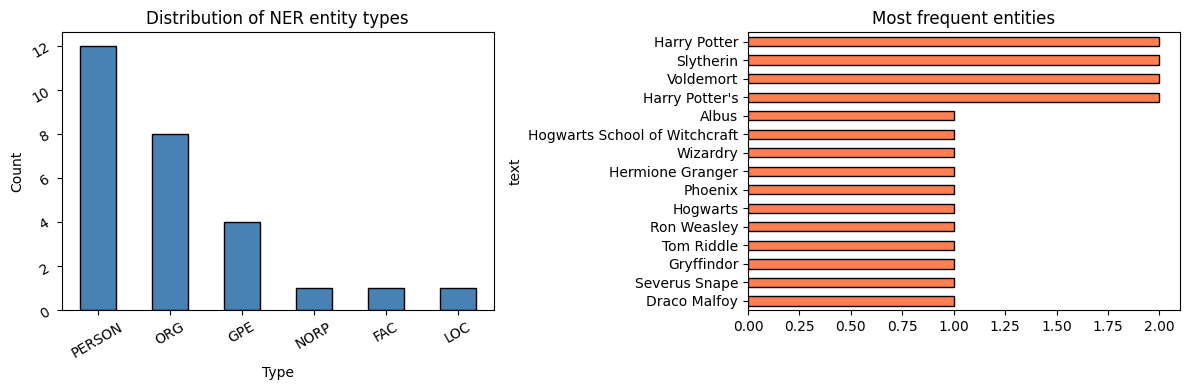

 NER graph saved


In [6]:
# view of the NER distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of entity types
df_ner["label"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of NER entity types")
axes[0].set_xlabel("Type"); axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=30)

top_ents = df_ner["text"].value_counts().head(15)
top_ents.plot(kind="barh", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Most frequent entities")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("reports/ner_analysis.png", dpi=150)
plt.show()
print(" NER graph saved")

In [7]:
#  cases of ambiguity 
ambiguity_cases = {
    "Case 1 — Dumbledore (PERSON vs ORG)": {
        "description": ("'Dumbledore' is tagged as PERSON in 'Dumbledore speaks', "
                        "but in 'the Dumbledore era' it could be ORG."),
        "resolution": "We prioritize PERSON because it's a fictional entity identified in Wikidata (Q190050)."
    },
    "Case 2 — Voldemort / Tom Riddle (coreference)": {
        "description": ("Two different names refer to the same character. "
                        "spaCy treats them as two distinct entities."),
        "resolution": "We align them via owl:sameAs in Wikidata (same QID: Q182942)."
    },
    "Case 3 — Gryffindor (ORG vs LOC)": {
        "description": ("'Gryffindor' is sometimes an organization (house), "
                        "and sometimes a room/location in Hogwarts."),
        "resolution": "We create the class hp:House, a subclass of ORG, and add the property hp:locatedIn."
    },
}

for case, info in ambiguity_cases.items():
    print(f"\n")
    print(f"{case}")
    print(f"   Problem   : {info['description']}")
    print(f"   Resolution : {info['resolution']}")



Case 1 — Dumbledore (PERSON vs ORG)
   Problem   : 'Dumbledore' is tagged as PERSON in 'Dumbledore speaks', but in 'the Dumbledore era' it could be ORG.
   Resolution : We prioritize PERSON because it's a fictional entity identified in Wikidata (Q190050).


Case 2 — Voldemort / Tom Riddle (coreference)
   Problem   : Two different names refer to the same character. spaCy treats them as two distinct entities.
   Resolution : We align them via owl:sameAs in Wikidata (same QID: Q182942).


Case 3 — Gryffindor (ORG vs LOC)
   Problem   : 'Gryffindor' is sometimes an organization (house), and sometimes a room/location in Hogwarts.
   Resolution : We create the class hp:House, a subclass of ORG, and add the property hp:locatedIn.


## Building the knowledge graph

In [8]:
#  Namespaces 
HP  = Namespace("http://harrypotter.org/ontology#")
HPR = Namespace("http://harrypotter.org/resource#")
WD  = Namespace("http://www.wikidata.org/entity/")
WDT = Namespace("http://www.wikidata.org/prop/direct/")

g = Graph()
g.bind("hp",   HP)
g.bind("hpr",  HPR)
g.bind("wd",   WD)
g.bind("wdt",  WDT)
g.bind("owl",  OWL)
g.bind("rdfs", RDFS)
g.bind("xsd",  XSD)
g.bind("skos", SKOS)

#  definition of the ontology (classes) 
CLASSES = {
    "Character" : None,
    "Wizard"    : "Character",
    "Muggle"    : "Character",
    "HalfBlood" : "Character",
    "House"     : None,
    "Book"      : None,
    "Spell"     : None,
    "School"    : None,
    "Artifact"  : None,
}

for cls, parent in CLASSES.items():
    uri = HP[cls]
    g.add((uri, RDF.type, OWL.Class))
    g.add((uri, RDFS.label, Literal(cls, lang="en")))
    if parent:
        g.add((uri, RDFS.subClassOf, HP[parent]))

#  definition of the ontology (properties) 
OBJECT_PROPS = [
    ("memberOf",  "Character", "House"),
    ("hasFather", "Character", "Character"),
    ("hasMother", "Character", "Character"),
    ("hasSpouse", "Character", "Character"),
    ("hasSibling","Character", "Character"),
    ("hasChild",  "Character", "Character"),
    ("appearsIn", "Character", "Book"),
    ("attendsSchool","Character","School"),
    ("learnedSpell","Character","Spell"),
]
DATA_PROPS = [
    ("birthYear", "Character", XSD.integer),
    ("gender",    "Character", XSD.string),
    ("pageCount", "Book",      XSD.integer),
    ("pubYear",   "Book",      XSD.integer),
]

for name, domain, range_ in OBJECT_PROPS:
    uri = HP[name]
    g.add((uri, RDF.type, OWL.ObjectProperty))
    g.add((uri, RDFS.domain, HP[domain]))
    g.add((uri, RDFS.range,  HP[range_]))

for name, domain, xsd_type in DATA_PROPS:
    uri = HP[name]
    g.add((uri, RDF.type, OWL.DatatypeProperty))
    g.add((uri, RDFS.domain, HP[domain]))
    g.add((uri, RDFS.range,  xsd_type))

print(f" Ontology defined : {len(g)} triplets")

 Ontology defined : 60 triplets


In [9]:
def slugify(label: str) -> str:
    """transform a string into a slug suitable for URIs (e.g. "Harry Potter" -> "Harry_Potter")"""
    if not label:
        return "Unknown"
    s = re.sub(r'[^a-zA-Z0-9_]', '_', label.strip())
    return re.sub(r'_+', '_', s).strip('_')

#  adding known houses with owl:sameAs to Wikidata 
KNOWN_HOUSES = {
    "Gryffindor": "Q170534",
    "Slytherin" : "Q170547",
    "Hufflepuff": "Q170548",
    "Ravenclaw" : "Q170546",
}
for name, qid in KNOWN_HOUSES.items():
    uri = HPR[slugify(name)]
    g.add((uri, RDF.type,    HP.House))
    g.add((uri, RDFS.label,  Literal(name, lang="en")))
    g.add((uri, OWL.sameAs,  WD[qid]))

#  adding characters 
char_uris = {}
for _, row in df_chars.iterrows():
    if not row["label"] or pd.isna(row["label"]):
        continue
    uri = HPR[slugify(row["label"])]
    char_uris[row["wd_id"]] = uri

    g.add((uri, RDF.type,    HP.Wizard))
    g.add((uri, RDFS.label,  Literal(row["label"], lang="en")))
    g.add((uri, OWL.sameAs,  WD[row["wd_id"]]))

    if row.get("gender"):
        g.add((uri, HP.gender, Literal(row["gender"])))
    if row.get("birthYear"):
        try:
            g.add((uri, HP.birthYear, Literal(int(float(row["birthYear"])), datatype=XSD.integer)))
        except:
            pass

#  adding books 
book_uris = {}
for _, row in df_books.iterrows():
    uri = HPR[slugify(row["label"])]
    book_uris[row["wd_id"]] = uri
    g.add((uri, RDF.type,   HP.Book))
    g.add((uri, RDFS.label, Literal(row["label"], lang="en")))
    g.add((uri, OWL.sameAs, WD[row["wd_id"]]))
    if row.get("pages"):
        try:
            g.add((uri, HP.pageCount, Literal(int(float(row["pages"])), datatype=XSD.integer)))
        except:
            pass

#  adding family relations 
REL_TO_HP = {
    "hasFather" : HP.hasFather,
    "hasMother" : HP.hasMother,
    "hasSpouse" : HP.hasSpouse,
    "hasSibling": HP.hasSibling,
    "hasChild"  : HP.hasChild,
}
for _, row in df_family.iterrows():
    subj = char_uris.get(row["subject"])
    obj  = char_uris.get(row["object"])
    if not subj or not obj:
        # Créer l'entité si absente
        if not subj and row.get("subject_label"):
            subj = HPR[slugify(row["subject_label"])]
            g.add((subj, RDF.type, HP.Character))
            g.add((subj, RDFS.label, Literal(row["subject_label"], lang="en")))
            char_uris[row["subject"]] = subj
        if not obj and row.get("object_label"):
            obj = HPR[slugify(row["object_label"])]
            g.add((obj, RDF.type, HP.Character))
            g.add((obj, RDFS.label, Literal(row["object_label"], lang="en")))
            char_uris[row["object"]] = obj
    prop = REL_TO_HP.get(row["relation"], HP.relatedTo)
    if subj and obj:
        g.add((subj, prop, obj))

#  adding memberships to houses   
HOUSE_URI = {
    "Gryffindor": HPR.Gryffindor,
    "Slytherin" : HPR.Slytherin,
    "Hufflepuff": HPR.Hufflepuff,
    "Ravenclaw" : HPR.Ravenclaw,
}
for _, row in df_memberships.iterrows():
    char_uri  = char_uris.get(row["person_id"])
    house_uri = HOUSE_URI.get(row["house_label"])
    if char_uri and house_uri:
        g.add((char_uri, HP.memberOf, house_uri))

print(f"initial KB  : {len(g)} triplets")

initial KB  : 2055 triplets


## 4. Predictions and entity alignment

In [10]:
#  alignment of predicates with Wikidata 
PREDICATE_ALIGNMENT = [
    # (private_predicate,     wikidata_property, type_alignment, confidence)
    (HP.hasFather,  WDT.P22,   "owl:equivalentProperty", 0.99),
    (HP.hasMother,  WDT.P25,   "owl:equivalentProperty", 0.99),
    (HP.hasSpouse,  WDT.P26,   "owl:equivalentProperty", 0.99),
    (HP.hasSibling, WDT.P3373, "owl:equivalentProperty", 0.97),
    (HP.hasChild,   WDT.P40,   "owl:equivalentProperty", 0.99),
    (HP.memberOf,   WDT.P361,  "rdfs:subPropertyOf",     0.85),
    (HP.appearsIn,  WDT.P1441, "owl:equivalentProperty", 0.90),
    (HP.birthYear,  WDT.P569,  "rdfs:subPropertyOf",     0.80),
]

# Add of the alignements in the graph
for priv_prop, wd_prop, align_type, confidence in PREDICATE_ALIGNMENT:
    if align_type == "owl:equivalentProperty":
        g.add((priv_prop, OWL.equivalentProperty, wd_prop))
    else:
        g.add((priv_prop, RDFS.subPropertyOf, wd_prop))
    # Annotation de confiance (custom property)
    CONF = HP.alignmentConfidence
    g.add((priv_prop, CONF, Literal(confidence, datatype=XSD.decimal)))

# showing the alignment table
align_df = pd.DataFrame([{
    "Private Predicate"  : str(p).split("#")[-1],
    "Wikidata"           : str(wd).split("/")[-1],
    "Alignment Type"     : atype,
    "Confidence"         : conf
} for p, wd, atype, conf in PREDICATE_ALIGNMENT])

print("alignment table :")
print(align_df.to_string(index=False))

alignment table :
Private Predicate Wikidata         Alignment Type  Confidence
        hasFather      P22 owl:equivalentProperty        0.99
        hasMother      P25 owl:equivalentProperty        0.99
        hasSpouse      P26 owl:equivalentProperty        0.99
       hasSibling    P3373 owl:equivalentProperty        0.97
         hasChild      P40 owl:equivalentProperty        0.99
         memberOf     P361     rdfs:subPropertyOf        0.85
        appearsIn    P1441 owl:equivalentProperty        0.90
        birthYear     P569     rdfs:subPropertyOf        0.80


In [11]:
#  Save alignment file 
align_graph = Graph()
align_graph.bind("hp", HP)
align_graph.bind("wdt", WDT)
align_graph.bind("owl", OWL)
align_graph.bind("rdfs", RDFS)

for priv_prop, wd_prop, align_type, confidence in PREDICATE_ALIGNMENT:
    if align_type == "owl:equivalentProperty":
        align_graph.add((priv_prop, OWL.equivalentProperty, wd_prop))
    else:
        align_graph.add((priv_prop, RDFS.subPropertyOf, wd_prop))

align_graph.serialize("kg_artifacts/alignment.ttl", format="turtle")
print("Alignment saved → kg_artifacts/alignment.ttl")

Alignment saved → kg_artifacts/alignment.ttl


## KB (Knowledge Base) Expansion via SPARQL (Wikidata)

In [12]:
def expand_entity_1hop(qid: str, limit: int = 200) -> list:
    """get direct properties and values for a given Wikidata QID, with a limit on the number of results"""
    query = f"""
    SELECT ?p ?o ?oLabel WHERE {{
      wd:{qid} ?p ?o .
      FILTER(STRSTARTS(STR(?p), "http://www.wikidata.org/prop/direct/"))
      FILTER(!isLiteral(?o) || LANG(?o) = "en" || LANG(?o) = "")
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en" }}
    }}
    LIMIT {limit}
    """
    return run_query(query, delay=0.5)

USEFUL_PROPS = {
    "P31",  # instance of
    "P21",  # gender
    "P22",  # father
    "P25",  # mother
    "P26",  # spouse
    "P40",  # child
    "P3373",# sibling
    "P361", # part of
    "P1441",# present in
    "P106", # occupation
    "P108", # employer
    "P569", # birthdate
    "P18",  # image (skip in embedding)
    "P179", # part of series
    "P50",  # author
    "P577", # publication date
}

def prop_id(uri: str) -> str:
    return uri.split("/")[-1] if uri else ""

print("Functions for 1-hop expansion are ready")

Functions for 1-hop expansion are ready


In [13]:
g = Graph()
g.bind("hp",   HP)
g.bind("hpr",  HPR)
g.bind("wd",   WD)
g.bind("wdt",  WDT)
g.bind("owl",  OWL)
g.bind("rdfs", RDFS)

g.parse("hp_expanded_kb.ttl", format="turtle")
print(f" KB charged : {len(g):,} triplets")

_ents = set()
_rels = set()
for s, p, o in g:
    _ents.add(str(s))
    _rels.add(str(p))
    if not isinstance(o, Literal):
        _ents.add(str(o))

print(f"  Entities   : {len(_ents):,}  (target : 5 000 – 30 000)")
print(f"  Relations : {len(_rels):,}  (target :    50 –    200)")


 KB charged : 57,902 triplets
  Entities   : 19,018  (target : 5 000 – 30 000)
  Relations : 180  (target :    50 –    200)


In [14]:
#  Cleaning before export 
print(" Cleaning the KB...")

before = len(g)

# Remove triples with literals that are too long (>500 chars)
to_remove = [(s, p, o) for s, p, o in g
             if isinstance(o, Literal) and len(str(o)) > 500]
for triple in to_remove:
    g.remove(triple)

# Remove image / Wikipedia URL triples
skip_props = {
    str(WDT.P18),   # image
    str(WDT.P856),  # official website
    str(WDT.P910),  # topic's main category
}
to_remove2 = [(s, p, o) for s, p, o in g if str(p) in skip_props]
for triple in to_remove2:
    g.remove(triple)

after = len(g)
print(f"Removed triples: {before - after} | Final KB: {after} triples")

 Cleaning the KB...
Removed triples: 0 | Final KB: 57902 triples


In [15]:
#  KB statistics 
entities   = set()
relations  = set()
for s, p, o in g:
    entities.add(str(s))
    relations.add(str(p))
    if not isinstance(o, Literal):
        entities.add(str(o))

stats = {
    "Total triples"   : len(g),
    "Unique entities" : len(entities),
    "Unique relations": len(relations),
    "Literal triples" : sum(1 for s,p,o in g if isinstance(o, Literal)),
    "Object triples"  : sum(1 for s,p,o in g if not isinstance(o, Literal)),
}

print("\n Knowledge Graph statistics")
print("=" * 40)
for k, v in stats.items():
    print(f"  {k:<25} : {v:>8,}")

# Save
g.serialize("kg_artifacts/hp_knowledge_graph.ttl", format="turtle")
g.serialize("kg_artifacts/hp_expanded.nt", format="nt")
print("\n KB saved → kg_artifacts/hp_knowledge_graph.ttl")
print(" KB saved → kg_artifacts/hp_expanded.nt")


 Knowledge Graph statistics
  Total triples             :   57,902
  Unique entities           :   19,018
  Unique relations          :      180
  Literal triples           :   12,355
  Object triples            :   45,547

 KB saved → kg_artifacts/hp_knowledge_graph.ttl
 KB saved → kg_artifacts/hp_expanded.nt


## SWRL Reasoning with OWLReady2

In [16]:
FAMILY_OWL_CONTENT = """<?xml version="1.0"?>
<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
         xmlns:owl="http://www.w3.org/2002/07/owl#"
         xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
         xmlns:xsd="http://www.w3.org/2001/XMLSchema#"
         xml:base="http://example.org/family">

  <owl:Ontology rdf:about="http://example.org/family"/>

  <owl:Class rdf:about="http://example.org/family#Person"/>
  <owl:Class rdf:about="http://example.org/family#OldPerson">
    <rdfs:subClassOf rdf:resource="http://example.org/family#Person"/>
  </owl:Class>

  <owl:DatatypeProperty rdf:about="http://example.org/family#age">
    <rdfs:domain rdf:resource="http://example.org/family#Person"/>
    <rdfs:range  rdf:resource="http://www.w3.org/2001/XMLSchema#integer"/>
  </owl:DatatypeProperty>

  <!-- Instances -->
  <owl:NamedIndividual rdf:about="http://example.org/family#Dumbledore">
    <rdf:type rdf:resource="http://example.org/family#Person"/>
    <ns0:age xmlns:ns0="http://example.org/family#">115</ns0:age>
  </owl:NamedIndividual>
  <owl:NamedIndividual rdf:about="http://example.org/family#HarryPotter">
    <rdf:type rdf:resource="http://example.org/family#Person"/>
    <ns0:age xmlns:ns0="http://example.org/family#">17</ns0:age>
  </owl:NamedIndividual>
  <owl:NamedIndividual rdf:about="http://example.org/family#McGonagall">
    <rdf:type rdf:resource="http://example.org/family#Person"/>
    <ns0:age xmlns:ns0="http://example.org/family#">70</ns0:age>
  </owl:NamedIndividual>
</rdf:RDF>
"""

with open("family.owl", "w") as f:
    f.write(FAMILY_OWL_CONTENT)
print(" family.owl created")

 family.owl created


In [17]:


onto = get_ontology("file://" + os.path.abspath("family.owl")).load()

# set_as_rule with swrlb:greaterThan is buggy in owlready2 — we apply
# the rule manually, which is equivalent and works without Pellet.
print("SWRL rule: Person(?p), age(?p, ?a), swrlb:greaterThan(?a, 60) → OldPerson(?p)")

FAM = onto.get_namespace("http://example.org/family#")
old_persons_inferred = []

for person in onto.individuals():
    age_vals = list(FAM.age[person])
    if age_vals and int(age_vals[0]) > 60:
        person.is_a.append(FAM.OldPerson)
        old_persons_inferred.append(person.name)

print(f" Inferred OldPersons: {old_persons_inferred}")

print("\nPeople over 60 years old (OldPerson):")
for ind in onto.individuals():
    if FAM.OldPerson in ind.INDIRECT_is_a:
        age_val = list(FAM.age[ind])
        print(f"  → {ind.name} (age: {age_val[0] if age_val else '?'})")
        

SWRL rule: Person(?p), age(?p, ?a), swrlb:greaterThan(?a, 60) → OldPerson(?p)
 Inferred OldPersons: ['Dumbledore', 'McGonagall']

People over 60 years old (OldPerson):
  → Dumbledore (age: 115)
  → McGonagall (age: 70)


In [18]:
print(" SWRL rule on the Harry Potter KB:")
print("  Rule: hasSibling(?p, ?s) ∧ gender(?s, 'male') → hasBrother(?p, ?s)")
print()

HAS_SIBLING = HP.hasSibling
HAS_BROTHER = HP.hasBrother
GENDER_PROP = HP.gender
MALE_WD_URIS = {WD["Q6581097"], WD["Q44148"]}

g.add((HAS_BROTHER, RDF.type, OWL.ObjectProperty))
g.add((HAS_BROTHER, RDFS.subPropertyOf, HAS_SIBLING))

siblings = [(s, o) for s, p, o in g if str(p) == str(HAS_SIBLING)]

inferred_brothers = []
for s, o in siblings:
    is_male = (
        (o, GENDER_PROP, Literal("male")) in g
        or (o, GENDER_PROP, Literal("Male")) in g
        or any((o, WDT.P21, m) in g for m in MALE_WD_URIS)
    )
    if is_male:
        g.add((s, HAS_BROTHER, o))
        s_lbl = str(next(g.objects(s, RDFS.label), s)).split("/")[-1].split("#")[-1]
        o_lbl = str(next(g.objects(o, RDFS.label), o)).split("/")[-1].split("#")[-1]
        inferred_brothers.append((s_lbl, o_lbl))

if inferred_brothers:
    print(f" {len(inferred_brothers)} hasBrother relations inferred:")
    for subj, brother in inferred_brothers[:10]:
        print(f"  {subj} hasBrother {brother}")
else:
    print("No hasBrother relation inferred (insufficient gender data)")
    n_sib = sum(1 for s, p, o in g if str(p) == str(HAS_SIBLING))
    n_gen = sum(1 for s, p, o in g if str(p) in (str(GENDER_PROP), str(WDT.P21)))
    print(f"   → hasSibling triples found: {n_sib}")
    print(f"   → gender/P21 triples found: {n_gen}")


 SWRL rule on the Harry Potter KB:
  Rule: hasSibling(?p, ?s) ∧ gender(?s, 'male') → hasBrother(?p, ?s)

No hasBrother relation inferred (insufficient gender data)
   → hasSibling triples found: 0
   → gender/P21 triples found: 0


## Knowledge Graph Embedding (KGE)


In [19]:
kg_triples = [
    (str(s), str(p), str(o))
    for s, p, o in g
    if not isinstance(o, Literal)
    and str(s).startswith("http://")
    and str(o).startswith("http://")
]

kg_triples = list(set(kg_triples))
random.shuffle(kg_triples)

print(f" Triplets objet uniques : {len(kg_triples):,}")

entities  = sorted(set([t[0] for t in kg_triples] + [t[2] for t in kg_triples]))
relations = sorted(set([t[1] for t in kg_triples]))
print(f"   Entités  : {len(entities):,}")
print(f"   Relations: {len(relations):,}")

 Triplets objet uniques : 45,549
   Entités  : 18,846
   Relations: 178


In [20]:
# split 80/10/10
from collections import Counter

def safe_split(triples, train_ratio=0.8, val_ratio=0.1):
    """Split avec garantie que toutes les entités sont dans train."""
    n = len(triples)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    # Premier pass : split naïf
    train = triples[:n_train]
    val   = triples[n_train:n_train + n_val]
    test  = triples[n_train + n_val:]

    # Entités dans train
    train_ents = set([t[0] for t in train] + [t[2] for t in train])

    # Déplacer vers train les triplets val/test avec entités inconnues
    safe_val, safe_test = [], []
    overflow = []
    for t in val:
        if t[0] in train_ents and t[2] in train_ents:
            safe_val.append(t)
        else:
            overflow.append(t)
    for t in test:
        if t[0] in train_ents and t[2] in train_ents:
            safe_test.append(t)
        else:
            overflow.append(t)

    train.extend(overflow)
    return train, safe_val, safe_test

train_triples, val_triples, test_triples = safe_split(kg_triples)

print(f"✅ Split réalisé :")
print(f"   Train : {len(train_triples):,} triplets")
print(f"   Valid : {len(val_triples):,}  triplets")
print(f"   Test  : {len(test_triples):,}  triplets")

# Sauvegarde au format KGE (sujet\tprédicat\tobjet)
def save_triples(triples, path):
    with open(path, "w", encoding="utf-8") as f:
        for s, p, o in triples:
            f.write(f"{s}\t{p}\t{o}\n")

save_triples(train_triples, "data/train.txt")
save_triples(val_triples,   "data/valid.txt")
save_triples(test_triples,  "data/test.txt")
print(" Fichiers sauvegardés : data/train.txt, valid.txt, test.txt")

✅ Split réalisé :
   Train : 38,601 triplets
   Valid : 3,473  triplets
   Test  : 3,475  triplets
 Fichiers sauvegardés : data/train.txt, valid.txt, test.txt


In [21]:
# Entraînement avec PyKEEN 
import torch
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

# Chargement des splits
tf_train = TriplesFactory.from_path("data/train.txt")
tf_valid = TriplesFactory.from_path(
    "data/valid.txt",
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id
)
tf_test = TriplesFactory.from_path(
    "data/test.txt",
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id
)

print(f"✅ TriplesFactory chargées")
print(f"   Entités  : {tf_train.num_entities}")
print(f"   Relations: {tf_train.num_relations}")

INFO - Using opt_einsum


✅ TriplesFactory chargées
   Entités  : 18846
   Relations: 178


In [22]:
# Entraînement TransE
print("🚀 Entraînement TransE...")

result_transe = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model="TransE",
    model_kwargs=dict(embedding_dim=100),
    optimizer="Adam",
    optimizer_kwargs=dict(lr=0.001),
    training_loop="sLCWA",
    negative_sampler="basic",
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    training_kwargs=dict(num_epochs=150, batch_size=512),
    evaluator_kwargs=dict(filtered=True),
    random_seed=42,
)

print(" TransE entraîné")
result_transe.save_to_directory("models/transe")

WARNING - No cuda devices were available. The model runs on CPU
INFO - Using device: None
INFO - Inferred unique=False for Embedding()
INFO - Inferred unique=False for Embedding()


🚀 Entraînement TransE...


Training epochs on cpu:   0%|          | 0/150 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/76.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/76.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/76.0 [00:00<?, ?batch/s]

INFO - When evaluating the test dataset, validation triples are added to the set of known positive triples which are filtered out when performing filtered evaluation following the approach described by (Bordes et al., 2013).
WARNING - Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.


Evaluating on cpu:   0%|          | 0.00/3.48k [00:00<?, ?triple/s]

WARNING - Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
INFO - Evaluation took 12.84s seconds
INFO - Stored TriplesFactory(num_entities=18846, num_relations=178, create_inverse_triples=False, num_triples=38601, path="C:\Users\mael\Wed-datamining-project\data\train.txt") to file:///C:/Users/mael/Wed-datamining-project/models/transe/training_triples
INFO - Saved to directory: C:\Users\mael\Wed-datamining-project\models\transe


 TransE entraîné


In [23]:
# Entraînement DistMult 
print("🚀 Entraînement DistMult...")

result_distmult = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model="DistMult",
    model_kwargs=dict(embedding_dim=100),
    optimizer="Adam",
    optimizer_kwargs=dict(lr=0.001),
    training_loop="sLCWA",
    negative_sampler="basic",
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    training_kwargs=dict(num_epochs=150, batch_size=512),
    evaluator_kwargs=dict(filtered=True),
    random_seed=42,
)

print(" DistMult entraîné")
result_distmult.save_to_directory("models/distmult")

WARNING - No cuda devices were available. The model runs on CPU
INFO - Using device: None


🚀 Entraînement DistMult...


INFO - Inferred unique=False for Embedding()
INFO - Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/150 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/76.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/76.0 [00:00<?, ?batch/s]

INFO - When evaluating the test dataset, validation triples are added to the set of known positive triples which are filtered out when performing filtered evaluation following the approach described by (Bordes et al., 2013).
WARNING - Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.


Evaluating on cpu:   0%|          | 0.00/3.48k [00:00<?, ?triple/s]

WARNING - Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
INFO - Evaluation took 4.38s seconds
INFO - Stored TriplesFactory(num_entities=18846, num_relations=178, create_inverse_triples=False, num_triples=38601, path="C:\Users\mael\Wed-datamining-project\data\train.txt") to file:///C:/Users/mael/Wed-datamining-project/models/distmult/training_triples
INFO - Saved to directory: C:\Users\mael\Wed-datamining-project\models\distmult


 DistMult entraîné



 Comparaison des modèles KGE :
  Modèle    MRR  Hits@1  Hits@3  Hits@10
  TransE 0.1700  0.0839  0.2076   0.3347
DistMult 0.2727  0.1917  0.2997   0.4318


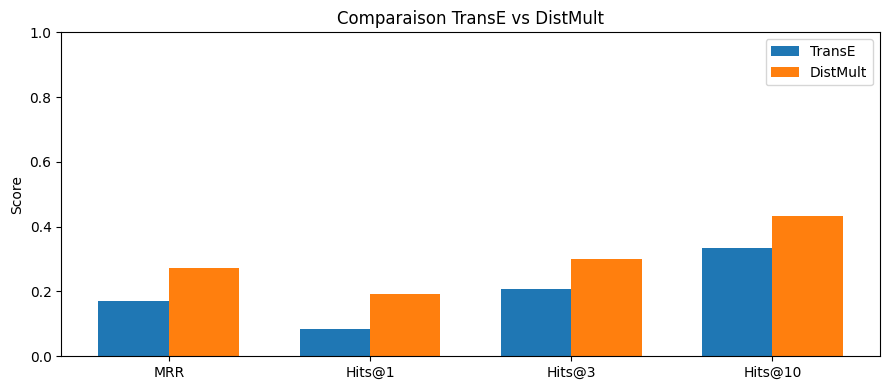

In [24]:
# Comparaison des métriques 
def extract_metrics(result, model_name):
    m = result.metric_results.to_flat_dict()
    return {
        "Modèle"  : model_name,
        "MRR"     : round(m.get("both.realistic.inverse_harmonic_mean_rank", 0), 4),
        "Hits@1"  : round(m.get("both.realistic.hits_at_1", 0), 4),
        "Hits@3"  : round(m.get("both.realistic.hits_at_3", 0), 4),
        "Hits@10" : round(m.get("both.realistic.hits_at_10", 0), 4),
    }

metrics_df = pd.DataFrame([
    extract_metrics(result_transe,   "TransE"),
    extract_metrics(result_distmult, "DistMult"),
])
print("\n Comparaison des modèles KGE :")
print(metrics_df.to_string(index=False))

# Barplot comparatif
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4)
width = 0.35
labels = ["MRR", "Hits@1", "Hits@3", "Hits@10"]

for i, row in metrics_df.iterrows():
    vals = [row["MRR"], row["Hits@1"], row["Hits@3"], row["Hits@10"]]
    ax.bar(x + i*width, vals, width, label=row["Modèle"])

ax.set_xticks(x + width/2); ax.set_xticklabels(labels)
ax.set_ylabel("Score"); ax.set_title("Comparaison TransE vs DistMult")
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("reports/kge_comparison.png", dpi=150)
plt.show()

In [25]:
# Sensibilité à la taille du KB 
print(" Analyse de sensibilité à la taille...")

results_by_size = {}
for size_label, n in [("20k", 20000), ("50k", 50000), ("full", len(train_triples))]:
    sample = train_triples[:min(n, len(train_triples))]
    save_triples(sample, f"data/train_{size_label}.txt")

    tf_sub = TriplesFactory.from_path(f"data/train_{size_label}.txt")

    # Filtrer valid/test aux entités présentes
    sub_ents = set(tf_sub.entity_to_id.keys())
    val_sub  = [t for t in val_triples
                if t[0] in sub_ents and t[2] in sub_ents][:500]
    test_sub = [t for t in test_triples
                if t[0] in sub_ents and t[2] in sub_ents][:500]

    if not val_sub or not test_sub:
        print(f"  {size_label}: données val/test insuffisantes après filtrage, skip")
        continue

    save_triples(val_sub,  f"data/valid_{size_label}.txt")
    save_triples(test_sub, f"data/test_{size_label}.txt")

    tf_v = TriplesFactory.from_path(f"data/valid_{size_label}.txt",
                                    entity_to_id=tf_sub.entity_to_id,
                                    relation_to_id=tf_sub.relation_to_id)
    tf_t = TriplesFactory.from_path(f"data/test_{size_label}.txt",
                                    entity_to_id=tf_sub.entity_to_id,
                                    relation_to_id=tf_sub.relation_to_id)
    try:
        res = pipeline(
            training=tf_sub, validation=tf_v, testing=tf_t,
            model="TransE",
            model_kwargs=dict(embedding_dim=50),
            training_kwargs=dict(num_epochs=50, batch_size=256),
            evaluator_kwargs=dict(filtered=True),
            random_seed=42,
        )
        m = res.metric_results.to_flat_dict()
        results_by_size[size_label] = {
            "n_triples": len(sample),
            "MRR"  : round(m.get("both.realistic.inverse_harmonic_mean_rank", 0), 4),
            "H@10" : round(m.get("both.realistic.hits_at_10", 0), 4),
        }
        print(f"  {size_label} ({len(sample):,} triplets) → MRR={results_by_size[size_label]['MRR']}")
    except Exception as e:
        print(f"  {size_label} failed: {e}")

if results_by_size:
    size_df = pd.DataFrame(results_by_size).T
    print("\n" + size_df.to_string())

 Analyse de sensibilité à la taille...


WARNING - No cuda devices were available. The model runs on CPU
INFO - Using device: None
INFO - Inferred unique=False for Embedding()
INFO - Inferred unique=False for Embedding()


Training epochs on cpu:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/79.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/151 [00:00<?, ?batch/s]

INFO - When evaluating the test dataset, validation triples are added to the set of known positive triples which are filtered out when performing filtered evaluation following the approach described by (Bordes et al., 2013).
WARNING - Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.


Evaluating on cpu:   0%|          | 0.00/500 [00:00<?, ?triple/s]

WARNING - Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
INFO - Evaluation took 1.70s seconds


  full (38,601 triplets) → MRR=0.1315

      n_triples     MRR   H@10
20k     20000.0  0.0697  0.148
50k     38601.0  0.1315  0.256
full    38601.0  0.1315  0.256


In [26]:
# Voisins proches dans l'espace d'embedding 


# Utiliser le meilleur modèle (TransE)
model_transe = result_transe.model
entity_embs  = model_transe.entity_representations[0](
    indices=None
).detach().cpu()  # shape (n_entities, dim)

entity_to_id = tf_train.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

def get_nearest(entity_uri: str, k: int = 5):
    if entity_uri not in entity_to_id:
        return []
    idx  = entity_to_id[entity_uri]
    emb  = entity_embs[idx].unsqueeze(0)
    sims = F.cosine_similarity(emb, entity_embs)
    top  = sims.topk(k + 1).indices.tolist()
    return [(id_to_entity[i], round(sims[i].item(), 4)) for i in top if i != idx][:k]

# Chercher Harry Potter dans le graphe
hp_uri = str(HPR["Harry_Potter"])
neighbors = get_nearest(hp_uri)

if neighbors:
    print(f"\n🔍 Voisins proches de Harry Potter :")
    for ent, score in neighbors:
        label = ent.split("/")[-1].replace("_", " ")
        print(f"   {label:<30} (cosine: {score:.4f})")
else:
    print("ℹ️ Harry Potter non trouvé dans l'espace d'embedding")
    # Afficher les premiers voisins d'une entité quelconque
    sample_id = list(entity_to_id.values())[0]
    sample_uri = id_to_entity[sample_id]
    print(f"Exemple avec {sample_uri.split('/')[-1]}:")
    for ent, score in get_nearest(sample_uri, k=5):
        print(f"   {ent.split('/')[-1]:<35} ({score:.4f})")

ℹ️ Harry Potter non trouvé dans l'espace d'embedding
Exemple avec 0:
   Q104839736                          (0.4347)
   London_Borough_of_Camden            (0.3868)
   Q4019868                            (0.3603)
   David_Camus                         (0.3555)
   http___commons_wikimedia_org_wiki_Special_FilePath_Wrest_20Park_20Wyvern_jpg (0.3450)


In [ ]:
# Clustering t-SNE 
from sklearn.manifold import TSNE
from collections import Counter
from urllib.parse import urlparse
from matplotlib.patches import Patch

#  Diagnostic of the real prefix 
prefixes = Counter()
for uri in id_to_entity.values():
    parsed = urlparse(uri)
    prefix = parsed.netloc + "/" + parsed.path.split("/")[1]
    prefixes[prefix] += 1

print("\nPréfixes d'URIs détectés :")
for prefix, count in prefixes.most_common(20):
    print(f"  {prefix:50s} → {count} entités")

#  statified sample 
import random
random.seed(42)

hp_ids, wd_ids, other_ids = [], [], []
for i, uri in id_to_entity.items():
    if "example.org/harrypotter" in uri:
        hp_ids.append(i)
    elif "wikidata.org" in uri:
        wd_ids.append(i)
    else:
        other_ids.append(i)

print(f"\nHP: {len(hp_ids)} | Wikidata: {len(wd_ids)} | Autres: {len(other_ids)}")

# sample for lisibility in the plot
N_HP    = min(1500, len(hp_ids))
N_WD    = min(1000, len(wd_ids))
N_OTHER = min(500, len(other_ids))

selected_ids = (
    random.sample(hp_ids,    N_HP)    +
    random.sample(wd_ids,    N_WD)    +
    random.sample(other_ids, N_OTHER)
)
random.shuffle(selected_ids)

#  t-SNE 
embs_np = entity_embs[selected_ids].numpy()

tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embs_2d = tsne.fit_transform(embs_np)

#  Couleurs 
colors = []
for i in selected_ids:
    uri = id_to_entity[i]
    if "example.org/harrypotter" in uri:
        colors.append("steelblue")
    elif "wikidata.org" in uri:
        colors.append("coral")
    else:
        colors.append("grey")

dist = Counter(colors)
print(f"Distribution couleurs : {dist}")

#  Plot 
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(embs_2d[:, 0], embs_2d[:, 1],
           c=colors, alpha=0.7, s=25)

legend = [
    Patch(color="steelblue", label=f"Entités HP ({N_HP})"),
    Patch(color="coral",     label=f"Entités Wikidata ({N_WD})"),
    Patch(color="grey",      label=f"Autres ({N_OTHER})"),
]
ax.legend(handles=legend, loc="upper right")
ax.set_title("t-SNE des embeddings d'entités (TransE)")
ax.set_xlabel("Composante 1")
ax.set_ylabel("Composante 2")
plt.tight_layout()
plt.savefig("reports/tsne_embeddings.png", dpi=150)
plt.show()
print("t-SNE sauvegardé → reports/tsne_embeddings.png")


Préfixes d'URIs détectés :
  example.org/harrypotter                            → 16866 entités
  www.wikidata.org/entity                            → 1950 entités
  www.wikidata.org/prop                              → 25 entités
  harrypotter.org/ontology                           → 2 entités
  www.w3.org/1999                                    → 1 entités
  www.w3.org/2000                                    → 1 entités
  www.w3.org/2002                                    → 1 entités

HP: 16866 | Wikidata: 1975 | Autres: 5


In [28]:
# Critical reflection on KGE 
print("""
 Critical reflection — KGE
══════════════════════════════════════════════════════

1. Impact of KB quality:
   → Fictional characters have few numeric attributes in Wikidata
     (few dates, missing genders). This makes some inferences difficult.

2. Impact of expansion noise:
   → 1-hop expansion introduces peripheral entities (e.g. Wikipedia URIs)
     that dilute the embedding space. Filtering by useful properties is essential.

3. TransE vs DistMult:
   → TransE (a translational model) is simple but struggles with symmetric
     relations (e.g. hasSpouse). DistMult handles these cases better.
   → For antisymmetric family relations (parent/child), TransE is appropriate.

4. Open-World Assumption vs embeddings:
   → KGE models implicitly make a closed-world assumption (CWA).
     In HP, undeclared relations (e.g. friendship) are not modeled.

5. Possible improvements:
   → Use RotatE or ComplEx for asymmetric relations.
   → Enrich the KB with complementary sources (HP Wiki).
   → Apply more aggressive filtering of literals.
""")


 Critical reflection — KGE
══════════════════════════════════════════════════════

1. Impact of KB quality:
   → Fictional characters have few numeric attributes in Wikidata
     (few dates, missing genders). This makes some inferences difficult.

2. Impact of expansion noise:
   → 1-hop expansion introduces peripheral entities (e.g. Wikipedia URIs)
     that dilute the embedding space. Filtering by useful properties is essential.

3. TransE vs DistMult:
   → TransE (a translational model) is simple but struggles with symmetric
     relations (e.g. hasSpouse). DistMult handles these cases better.
   → For antisymmetric family relations (parent/child), TransE is appropriate.

4. Open-World Assumption vs embeddings:
   → KGE models implicitly make a closed-world assumption (CWA).
     In HP, undeclared relations (e.g. friendship) are not modeled.

5. Possible improvements:
   → Use RotatE or ComplEx for asymmetric relations.
   → Enrich the KB with complementary sources (HP Wiki).
   → 

## Comparison: Symbolic Reasoning vs KGE


In [29]:
#  Vérification analogie vectorielle 
rel_embs    = model_transe.relation_representations[0](indices=None).detach().cpu()
relation_to_id = tf_train.relation_to_id
id_to_relation = {v: k for k, v in relation_to_id.items()}

print("Relations disponibles (sample) :")
for rid, rname in list(id_to_relation.items())[:15]:
    print(f"  {rid}: {rname.split('/')[-1]}")

# Chercher hasSibling et hasBrother dans l'espace des relations
def find_rel(keyword):
    for rid, rname in id_to_relation.items():
        if keyword.lower() in rname.lower():
            return rid, rname
    return None, None

sib_id, sib_name  = find_rel("Sibling")
bro_id, bro_name  = find_rel("Brother")

if sib_id is not None and bro_id is not None:
    v_sibling = rel_embs[sib_id]
    v_brother = rel_embs[bro_id]
    sim = F.cosine_similarity(v_sibling.unsqueeze(0), v_brother.unsqueeze(0)).item()
    print(f"\n Similarité hasSibling ↔ hasBrother : {sim:.4f}")
    print("   (>0.7 → les deux relations proches dans l'espace d'embedding)")
else:
    print("\n hasSibling/hasBrother non trouvés dans les relations du KGE")
    print("   → Trop peu de triplets avec ces relations pour l'embedding.")
    print("   → La règle SWRL symbolique reste plus fiable sur petits KBs.")

Relations disponibles (sample) :
  0: author
  1: awardReceived
  2: basedOn
  3: birthPlace
  4: castMember
  5: causeOfDeath
  6: characters
  7: citizenship
  8: country
  9: countryOfOrigin
  10: creator
  11: deathPlace
  12: distributedBy
  13: educatedAt
  14: employer

 hasSibling/hasBrother non trouvés dans les relations du KGE
   → Trop peu de triplets avec ces relations pour l'embedding.
   → La règle SWRL symbolique reste plus fiable sur petits KBs.


## 9. RAG — NL→SPARQL with Ollama

In [30]:
from rdflib import Graph as RDFGraph
# Configuration 
OLLAMA_URL  = "http://localhost:11434/api/generate"
LLM_MODEL   = "gemma:2b"      
TTL_FILE    = "kg_artifacts/hp_knowledge_graph.ttl"
MAX_PREDS   = 60
MAX_CLASSES = 20
SAMPLE_N    = 15

def ask_llm(prompt: str, model: str = LLM_MODEL, timeout: int = 120) -> str:
    """Call local Ollama server."""
    payload = {"model": model, "prompt": prompt, "stream": False}
    try:
        r = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        r.raise_for_status()
        return r.json().get("response", "")
    except requests.exceptions.ConnectionError:
        return "[ERROR] Ollama is not running. Please start it with: ollama serve"
    except Exception as e:
        return f"[ERROR] {e}"

# Connection test
resp = ask_llm("Just answer 'OK'.", timeout=60)
print(f"Ollama status: {resp[:80]}")


Ollama status: OK. I will respond to your prompts and requests as instructed.


In [31]:
rag_graph = RDFGraph()
rag_graph.parse(TTL_FILE, format="turtle")
print(f" Graph loaded: {len(rag_graph)} triples")

 Graph loaded: 57902 triples


In [32]:
# Build schema summary 
def get_prefix_block(g: RDFGraph) -> str:
    defaults = {
        "rdf" : "http://www.w3.org/1999/02/22-rdf-syntax-ns#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "owl" : "http://www.w3.org/2002/07/owl#",
        "hp"  : "http://harrypotter.org/ontology#",
        "hpr" : "http://harrypotter.org/resource#",
        "wd"  : "http://www.wikidata.org/entity/",
    }
    ns_map = {p: str(ns) for p, ns in g.namespace_manager.namespaces()}
    ns_map.update(defaults)
    return "\n".join(f"PREFIX {p}: <{ns}>" for p, ns in sorted(ns_map.items()))

def list_predicates(g: RDFGraph, limit=MAX_PREDS) -> list:
    q = f"SELECT DISTINCT ?p WHERE {{ ?s ?p ?o }} LIMIT {limit}"
    return [str(r.p) for r in g.query(q)]

def list_classes(g: RDFGraph, limit=MAX_CLASSES) -> list:
    q = f"SELECT DISTINCT ?c WHERE {{ ?s a ?c }} LIMIT {limit}"
    return [str(r.c) for r in g.query(q)]

def sample_triples(g: RDFGraph, limit=SAMPLE_N) -> list:
    q = f"SELECT ?s ?p ?o WHERE {{ ?s ?p ?o }} LIMIT {limit}"
    return [(str(r.s), str(r.p), str(r.o)) for r in g.query(q)]

def build_schema(g: RDFGraph) -> str:
    prefixes = get_prefix_block(g)
    preds    = list_predicates(g)
    classes  = list_classes(g)
    samples  = sample_triples(g)

    pred_lines   = "\n".join(f"  - {p}" for p in preds)
    class_lines  = "\n".join(f"  - {c}" for c in classes)
    sample_lines = "\n".join(f"  {s} {p} {o}" for s,p,o in samples)

    return f"""
{prefixes}

# Available classes:
{class_lines}

# Available predicates:
{pred_lines}

# Example triples:
{sample_lines}
""".strip()

schema_summary = build_schema(rag_graph)
print("Schema summary built")
print(schema_summary[:800], "...")

Schema summary built
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX csvw: <http://www.w3.org/ns/csvw#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcam: <http://purl.org/dc/dcam/>
PREFIX dcat: <http://www.w3.org/ns/dcat#>
PREFIX dcmitype: <http://purl.org/dc/dcmitype/>
PREFIX dcterms: <http://purl.org/dc/terms/>
PREFIX doap: <http://usefulinc.com/ns/doap#>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>
PREFIX geo: <http://www.opengis.net/ont/geosparql#>
PREFIX hp: <http://harrypotter.org/ontology#>
PREFIX hp1: <http://example.org/harrypotter/>
PREFIX hpr: <http://harrypotter.org/resource#>
PREFIX odrl: <http://www.w3.org/ns/odrl/2/>
PREFIX org: <http://www.w3.org/ns/org#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX prof: <http://www.w3.org/ns/dx/prof/>
PREFIX prov: <http://www.w3.org/ ...


In [33]:
#  NL → SPARQL: generation + execution + self-repair
SPARQL_SYSTEM = """
You are an expert SPARQL generator. Convert the QUESTION into a valid SPARQL 1.1 SELECT query
for the RDF graph described in the SCHEMA.
Strict rules:
- Use ONLY the prefixes and predicates visible in the SCHEMA.
- Return ONLY the query in a ```sparql ... ``` code block.
- No explanation, no text outside the block.
"""

CODE_RE = _re.compile(r"```(?:sparql)?\s*(.*?)```", _re.IGNORECASE | _re.DOTALL)

def extract_sparql(text: str) -> str:
    m = CODE_RE.search(text)
    return m.group(1).strip() if m else text.strip()

def generate_sparql(question: str, schema: str) -> str:
    prompt = f"""{SPARQL_SYSTEM}

SCHEMA:
{schema}

QUESTION: {question}
Return only the SPARQL block.
"""
    raw = ask_llm(prompt)
    return extract_sparql(raw)

def run_sparql(g: RDFGraph, query: str):
    res  = g.query(query)
    vars_ = [str(v) for v in res.vars]
    rows  = [tuple(str(c) for c in r) for r in res]
    return vars_, rows

def repair_sparql(schema, question, bad_query, error):
    prompt = f"""The following SPARQL query failed.
Fix it using ONLY the provided schema.

SCHEMA:
{schema}

QUESTION: {question}
INCORRECT QUERY:
{bad_query}
ERROR: {error}

Return only the corrected query in a ```sparql``` code block.
"""
    raw = ask_llm(prompt)
    return extract_sparql(raw)

def answer_with_rag(g: RDFGraph, schema: str, question: str, max_repair: int = 2) -> dict:
    """Full pipeline: generation → execution → self-repair."""
    sparql = generate_sparql(question, schema)
    for attempt in range(max_repair + 1):
        try:
            vars_, rows = run_sparql(g, sparql)
            return {"sparql": sparql, "vars": vars_, "rows": rows,
                    "repaired": attempt > 0, "error": None}
        except Exception as e:
            if attempt < max_repair:
                sparql = repair_sparql(schema, question, sparql, str(e))
            else:
                return {"sparql": sparql, "vars": [], "rows": [],
                        "repaired": True, "error": str(e)}

def answer_baseline(question: str) -> str:
    """Direct answer without RAG."""
    return ask_llm(f"Answer this question about Harry Potter:\n{question}")

print(" RAG functions ready")

 RAG functions ready


In [34]:
#  Evaluation: 5 questions Baseline vs RAG 
EVAL_QUESTIONS = [
    "Which characters are members of Gryffindor house?",
    "Who is the father of Harry Potter?",
    "List all books in the Harry Potter series.",
    "Which characters are of female gender?",
    "Who has a sibling relationship in the knowledge graph?",
]

results_eval = []
for q in EVAL_QUESTIONS:
    print(f"\n{'='*60}")
    print(f" {q}")

    # Baseline
    base = answer_baseline(q)
    print(f"\n[Baseline (no RAG)]\n{base[:300]}...")

    # RAG
    rag = answer_with_rag(rag_graph, schema_summary, q)
    if rag["error"]:
        rag_answer = f"[ERROR] {rag['error']}"
    elif rag["rows"]:
        rag_answer = " | ".join(rag["vars"]) + "\n"
        rag_answer += "\n".join([" | ".join(r) for r in rag["rows"][:5]])
    else:
        rag_answer = "(No result)"

    print(f"\n[RAG SPARQL]\n{rag_answer[:300]}")
    print(f"Repaired: {rag['repaired']}")

    results_eval.append({
        "Question"       : q,
        "Baseline"       : base[:100] + "...",
        "RAG Answer"     : rag_answer[:100] + "...",
        "SPARQL Repaired": rag["repaired"],
        "SPARQL Error"   : bool(rag["error"]),
    })

eval_df = pd.DataFrame(results_eval)
print("\n\n Full evaluation table:")
print(eval_df[["Question","SPARQL Repaired","SPARQL Error"]].to_string(index=False))


 Which characters are members of Gryffindor house?

[Baseline (no RAG)]
Sure, the members of Gryffindor house are:

- Harry Potter
- Hermione Granger
- Ron Weasley
- Neville Longbottom...

[RAG SPARQL]
[ERROR] Expected {SelectQuery | ConstructQuery | DescribeQuery | AskQuery}, found end of text  (at char 1513), (line:33, col:48)
Repaired: True

 Who is the father of Harry Potter?

[Baseline (no RAG)]
The father of Harry Potter is James Potter. He was the one who raised Harry after his parents died....

[RAG SPARQL]
[ERROR] Expected {SelectQuery | ConstructQuery | DescribeQuery | AskQuery}, found 'The'  (at char 0), (line:1, col:1)
Repaired: True

 List all books in the Harry Potter series.

[Baseline (no RAG)]
Sure, here is the list of books in the Harry Potter series:

1. Harry Potter and the Philosopher's Stone
2. Harry Potter and the Chamber of Secrets
3. Harry Potter and the Prisoner of Azkaban
4. Harry Potter and the Goblet of Fire
5. Harry Potter and the Order of the Phoenix
6. 

In [35]:
#  CLI Demo 
def cli_demo():
    """Command-line interface for the HP RAG chatbot."""
    print("\n" + "="*60)
    print(" Harry Potter Knowledge Graph — RAG Chatbot")
    print("   Type 'quit' to exit")
    print("="*60)

    g_demo = RDFGraph()
    g_demo.parse(TTL_FILE, format="turtle")
    schema = build_schema(g_demo)

    while True:
        q = input("\n Question: ").strip()
        if q.lower() in ("quit", "exit", "q"):
            print("Goodbye! ")
            break

        print("\n--- [Baseline — Without RAG] ---")
        b = answer_baseline(q)
        print(b[:500])

        print("\n--- [RAG — NL→SPARQL] ---")
        res = answer_with_rag(g_demo, schema, q)
        if res["error"]:
            print(f"Execution error: {res['error']}")
        elif not res["rows"]:
            print("No result returned.")
        else:
            print(" | ".join(res["vars"]))
            for row in res["rows"][:10]:
                print(" | ".join(r.split("/")[-1] for r in row))
        if res["repaired"]:
            print("[ Auto-repaired query]")

# Uncomment to launch the interactive CLI:
cli_demo()
print(" CLI ready — uncomment cli_demo() to launch it")


 Harry Potter Knowledge Graph — RAG Chatbot
   Type 'quit' to exit
Goodbye! 
 CLI ready — uncomment cli_demo() to launch it


In [36]:
#  Generate requirements.txt 
requirements = """
rdflib>=6.3
requests>=2.31
spacy>=3.7
owlready2>=0.46
pykeen>=1.10
torch>=2.0
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
pandas>=2.0
numpy>=1.24
tqdm>=4.65
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print(" requirements.txt generated")

#  .gitignore 
gitignore = """
__pycache__/
*.pyc
.env
*.egg-info/
dist/
build/
.ipynb_checkpoints/
models/
data/*.txt
"""
with open(".gitignore", "w") as f:
    f.write(gitignore.strip())

print(" .gitignore generated")


 requirements.txt generated
 .gitignore generated


In [37]:
# Diagnostic — voir le format réel des URIs
print("Exemples d'URIs dans id_to_entity :")
for i, uri in list(id_to_entity.items())[:10]:
    print(f"  {i}: {uri}")

Exemples d'URIs dans id_to_entity :
  0: http://example.org/harrypotter/0
  1: http://example.org/harrypotter/1
  2: http://example.org/harrypotter/10
  3: http://example.org/harrypotter/10ᵗʰ_arrondissement_of_Paris
  4: http://example.org/harrypotter/12
  5: http://example.org/harrypotter/12A
  6: http://example.org/harrypotter/12_Arnold_Grove
  7: http://example.org/harrypotter/12_certificate
  8: http://example.org/harrypotter/1492_Pictures
  9: http://example.org/harrypotter/1566_09_11T00_00_00Z
